In [1]:
#Install dependencies
#!pip install -q tensorflow tensorflow_hub tensorflow_io kaggle

#Importing necessary modules
from google.colab import files
import zipfile
import pandas as pd
import os
from google.colab import files

#Preprocessing modules:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pickle
import numpy as np
from sklearn.preprocessing import LabelEncoder

#Model modules:
import librosa
import tensorflow as tf
import tensorflow_hub as hub
import soundfile as sf
import tensorflow as tf
import tensorflow_hub as hub

#Evaulation metrics:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")


2026-03-02 00:41:31.713225: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772412091.931076      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772412091.992670      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772412092.501666      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772412092.501718      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772412092.501722      55 computation_placer.cc:177] computation placer alr

In [2]:
# Generating the labelled csv file since the dataset does not come with one:


wav_dir = "/kaggle/input/insectsound1000/InsectSound1000"


species_to_category = {
    "Palomena_prasina": "pest",
    "Nezara_viridula": "pest",
    "Halyomorpha_halys": "pest",
    "Rhaphigaster_nebulos": "pest",
    "Bradysia_difformis": "pest",
    "Myzus_persicae": "pest",
    "Trialeurodes_vaporariorum": "pest",
    "Tuta_absoluta": "pest",

    "Bombus_terrestris": "beneficial",
    "Episyrphus_balteatus": "beneficial",
    "Coccinella_septempunctata": "beneficial",
    "Aphidoletes_aphidimyza": "beneficial"
}

data = []

for filename in os.listdir(wav_dir):
    if filename.endswith(".wav"):
        parts = filename.split("_")

        if len(parts) >= 3:
            species = parts[1] + "_" + parts[2]

            if species in species_to_category:
                category = species_to_category[species]

                full_path = os.path.join(wav_dir, filename)

                data.append({
                    "filepath": full_path,
                    "species": species,
                    "category": category
                })

df = pd.DataFrame(data)

csv_path = "/kaggle/working/insect_labels_binary.csv"
df.to_csv(csv_path, index=False)

print("CSV saved at:", csv_path)
print("Total samples:", len(df))
print("\nCategory distribution:\n")

#Converting "category" column to binary values for easy processing

df["category"] = df["category"].map({
    "pest": 0,
    "beneficial": 1
})

#Displaying the category value spread
print(df["category"].value_counts())




CSV saved at: /kaggle/working/insect_labels_binary.csv
Total samples: 165982

Category distribution:

category
0    102076
1     63906
Name: count, dtype: int64


In [3]:
# Label file
metadata = pd.read_csv("/kaggle/working/insect_labels_binary.csv")
metadata.head()

,filepath,species,category
0,/kaggle/input/insectsound1000/InsectSound1000/...,Episyrphus_balteatus,beneficial
1,/kaggle/input/insectsound1000/InsectSound1000/...,Halyomorpha_halys,pest
2,/kaggle/input/insectsound1000/InsectSound1000/...,Nezara_viridula,pest
3,/kaggle/input/insectsound1000/InsectSound1000/...,Nezara_viridula,pest
4,/kaggle/input/insectsound1000/InsectSound1000/...,Bradysia_difformis,pest


In [4]:
#Directory verification
fp = "/kaggle/input/insectsound1000/InsectSound1000"
audio = os.listdir(fp)
print(f"Total files: ",len(audio))
print("Sample files: ", audio[:5])

Total files:  165982
Sample files:  ['2023613-16-37_Episyrphus_balteatus_000064_s71_ch0.wav', '2022524-16-36_Halyomorpha_halys_000038_s48_ch0.wav', '2022512-17-17_Nezara_viridula_000056_s2_ch0.wav', '202268-16-20_Nezara_viridula_000030_s15_ch0.wav', '2022329-13-41_Bradysia_difformis_000021_s13_ch0.wav']


In [5]:
print(df.head())

                                            filepath               species  \
0  /kaggle/input/insectsound1000/InsectSound1000/...  Episyrphus_balteatus   
1  /kaggle/input/insectsound1000/InsectSound1000/...     Halyomorpha_halys   
2  /kaggle/input/insectsound1000/InsectSound1000/...       Nezara_viridula   
3  /kaggle/input/insectsound1000/InsectSound1000/...       Nezara_viridula   
4  /kaggle/input/insectsound1000/InsectSound1000/...    Bradysia_difformis   

   category  
0         1  
1         0  
2         0  
3         0  
4         0  


In [6]:
# Downsampling the pest data to minimize data imbalance

# Count samples per class
print("Before downsampling:")
print(df["category"].value_counts())

# Separate pest and beneficial
pest_df = df[df["category"] == 0]          # pests
beneficial_df = df[df["category"] == 1]    # beneficials

# Downsample pest to match beneficial count
pest_downsampled = pest_df.sample(
    n=len(beneficial_df), 
    random_state=42
)

# Combine back into a balanced dataset
balanced_df = pd.concat([pest_downsampled, beneficial_df])

# Shuffle rows
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("After downsampling:")
print(balanced_df["category"].value_counts())

Before downsampling:
category
0    102076
1     63906
Name: count, dtype: int64
After downsampling:
category
1    63906
0    63906
Name: count, dtype: int64


In [7]:
# Extracting labels and filepaths

X = []
y = []

species_to_category = {
    "Palomena_prasina": 0,
    "Nezara_viridula": 0,
    "Halyomorpha_halys": 0,
    "Rhaphigaster_nebulos": 0,
    "Bradysia_difformis": 0,
    "Myzus_persicae": 0,
    "Trialeurodes_vaporariorum": 0,
    "Tuta_absoluta": 0,

    "Bombus_terrestris": 1,
    "Episyrphus_balteatus": 1,
    "Coccinella_septempunctata": 1,
    "Aphidoletes_aphidimyza": 1
}


X = balanced_df['filepath'].values;
y = balanced_df['category'].values;

print("Total files:", len(X))
print("Example:", X[0], "→", y[0])


Total files: 127812
Example: /kaggle/input/insectsound1000/InsectSound1000/2023424-16-23_Coccinella_septempunctata_000059_s11_ch0.wav → 1


In [8]:
# Verification of sampling rate to make sure it says as 16k


file_path = X[0]  # first audio file
_, sr = librosa.load(file_path, sr=None)

print("Sampling rate:", sr)


Sampling rate: 16000


In [9]:
# Encoding labels for compatability with model


le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(le.classes_)

print("Number of classes:", num_classes)
print("Encoded example:", y_encoded[:5])
print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(i, "→", cls)


Number of classes: 2
Encoded example: [1 1 0 1 0]
Class mapping:
0 → 0
1 → 1


In [10]:
#Initializing to NumPy arrays for better performance
X = np.array(X)
y_encoded = np.array(y_encoded)
print(X[:5],"\n",y_encoded[:5])

['/kaggle/input/insectsound1000/InsectSound1000/2023424-16-23_Coccinella_septempunctata_000059_s11_ch0.wav'
 '/kaggle/input/insectsound1000/InsectSound1000/2023427-16-31_Bombus_terrestris_000056_s104_ch1.wav'
 '/kaggle/input/insectsound1000/InsectSound1000/202297-15-37_Palomena_prasina_000001_s85_ch1.wav'
 '/kaggle/input/insectsound1000/InsectSound1000/2022324-13-48_Aphidoletes_aphidimyza_000073_s12_ch0.wav'
 '/kaggle/input/insectsound1000/InsectSound1000/2022524-16-36_Halyomorpha_halys_000015_s96_ch2.wav'] 
 [1 1 0 1 0]


In [11]:
# Function to load audio waveform from each file 



def load_mono_py(file_path):
    if isinstance(file_path, tf.Tensor):
        file_path = file_path.numpy()
    if isinstance(file_path, (bytes, bytearray)):
        file_path = file_path.decode("utf-8")
    if isinstance(file_path, np.ndarray) and np.issubdtype(file_path.dtype, np.floating):
        return file_path.astype(np.float32)
    if isinstance(file_path, str):
        data, sr = sf.read(file_path)
        if len(data.shape) > 1:
            data = np.mean(data, axis=1)
        if sr != 16000:
            data = librosa.resample(data, orig_sr=sr, target_sr=16000)
        return data.astype(np.float32)
    raise ValueError(f"Unsupported type: {type(file_path)}")

def load_mono_tf(file_path):
    waveform = tf.py_function(
        load_mono_py,
        [file_path],
        tf.float32
    )
    waveform.set_shape([None])  
    return waveform


yamnet = hub.load('https://tfhub.dev/google/yamnet/1')

# Program to extract the relevant embeddings from the waveforms in the previous fn


def extembed(file_path, label):
    waveform = load_mono_tf(file_path)
    
    scores, embeddings, spectrogram = yamnet(waveform)
    mean = tf.reduce_mean(embeddings, axis=0)
    std  = tf.math.reduce_std(embeddings, axis=0)
    embedding = tf.concat([mean, std], axis=0)

    # # Average temporal embeddings
    # mean = tf.reduce_mean(embeddings, axis=0) 
    # #emean = tf.reduce_max(embeddings, axis=0) #In case mean does not work
    # std = tf.math.reduce_std(embeddings, axis=0)
    # embedding = tf.concat([mean, std], axis=0)

    return embedding, label


2026-03-02 00:42:22.338133: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
num = len(set(y_encoded))

AUTOTUNE = tf.data.AUTOTUNE

dataset = tf.data.Dataset.from_tensor_slices((X, y_encoded)) # Converts arrays into TensorFlow datasets

dataset = (
    dataset
    .shuffle(10000)
    .map(extembed, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(512)
    .prefetch(AUTOTUNE)
)


In [13]:
# Classification phase: Dense NN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Main dataset split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

#Training and validation datasets:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .shuffle(10000)
    .map(extembed, num_parallel_calls=AUTOTUNE)
    .batch(1024)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(extembed, num_parallel_calls=AUTOTUNE)
    .batch(1024)
    .prefetch(AUTOTUNE)
)


In [14]:
# CNN Architecture
# model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(2048,)),   # matches pooled embedding
#     tf.keras.layers.Dense(512, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(256, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(1, activation='sigmoid')
# ])

# GPU-bound distribution
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2048,)),   # pooled embedding
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
    )

    

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


In [15]:
for x_batch, y_batch in train_ds.take(1):
    print(x_batch.shape, y_batch.shape)

(1024, 2048) (1024,)


In [16]:
# Code to handle class imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
count = 0;
for k,v in class_weight_dict.items():
    print("Key: ",k,"\n","Value: ",v)
    count += 1;
    if count > 5: break;

Key:  0 
 Value:  1.0000097801423988
Key:  1 
 Value:  0.9999902200488997


In [17]:
# Model Compilation
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180,673 (4.50 MB)

 Trainable params: 1,180,673 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Adding callbacks - Why?
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.h5",
        save_best_only=True
    )
]


In [19]:
# import soundfile as sf

# for f in X[:1000]:
#     try:
#         info = sf.info(f)
#         print(f"{f}: channels={info.channels}, subtype={info.subtype}")
#     except Exception as e:
#         print(f"Corrupt or unreadable: {f} ({e})")


In [20]:
 #Model Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    class_weight=class_weight_dict,
    callbacks=callbacks
)





Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.6822 - loss: 0.5957 

100/100 ━━━━━━━━━━━━━━━━━━━━ 1962s 20s/step - accuracy: 0.6826 - loss: 0.5950 - val_accuracy: 0.7910 - val_loss: 0.4538
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.7880 - loss: 0.4527 

100/100 ━━━━━━━━━━━━━━━━━━━━ 1824s 18s/step - accuracy: 0.7881 - loss: 0.4526 - val_accuracy: 0.8201 - val_loss: 0.4068
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.8201 - loss: 0.4020 

100/100 ━━━━━━━━━━━━━━━━━━━━ 1879s 19s/step - accuracy: 0.8202 - loss: 0.4019 - val_accuracy: 0.8384 - val_loss: 0.3672


In [21]:
#Model evaluation
val_loss, val_acc = model.evaluate(val_ds)
print("Validation Accuracy:", val_acc)


25/25 ━━━━━━━━━━━━━━━━━━━━ 296s 11s/step - accuracy: 0.8412 - loss: 0.3651
Validation Accuracy: 0.8383992314338684


In [22]:
# Classification report

y_true = []
y_pred = []

for embeddings, labels in val_ds:
    preds = model.predict(embeddings)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype("int32").flatten())

print(classification_report(y_true, y_pred))


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
 

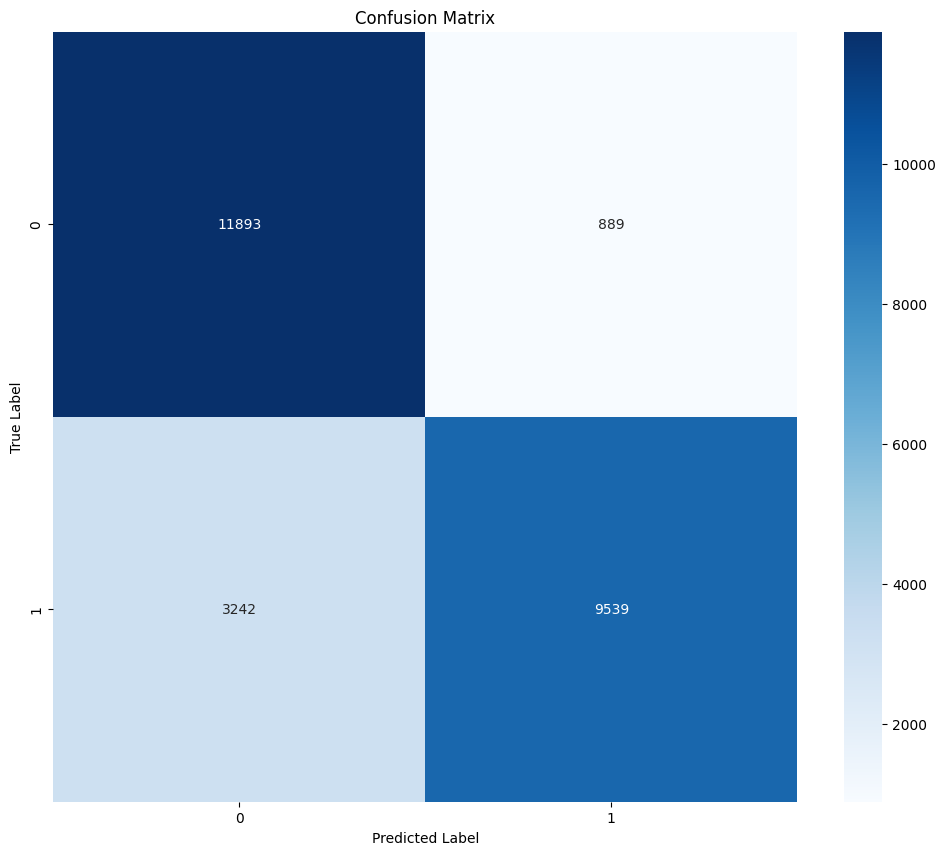

In [23]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
cls = le.classes_
labels = np.unique(np.concatenate((y_val, y_pred)))
comb = [cls[i] for i in labels]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=comb, yticklabels=comb)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


# XAI COMPONENTS


SHAP shape: (50, 2048)
Input shape: (50, 2048)


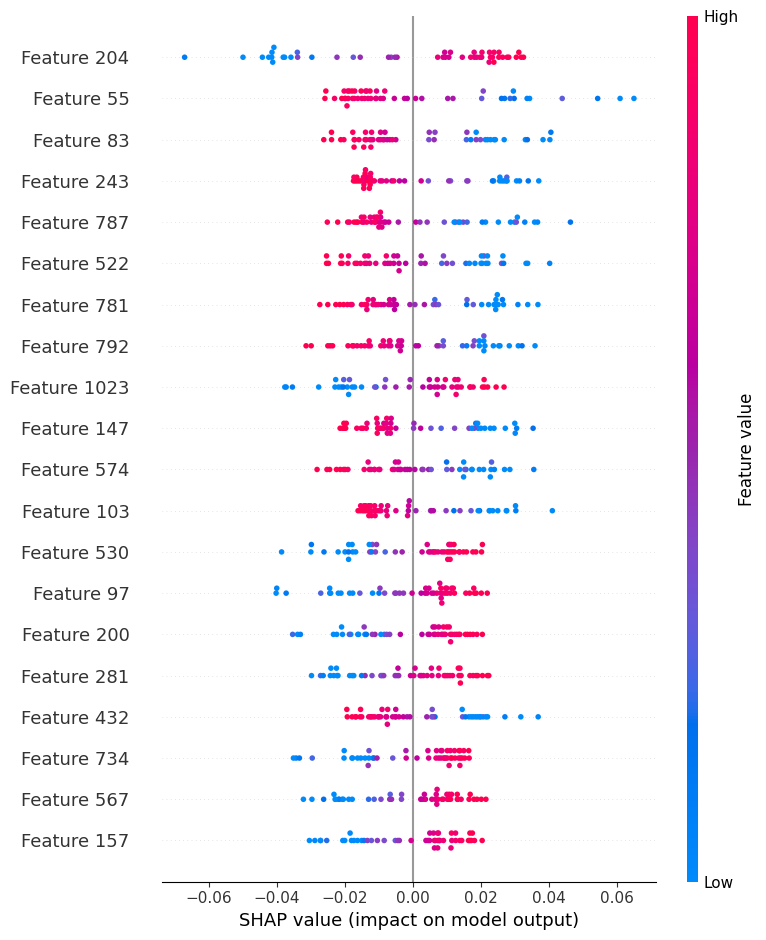

In [24]:
# =========================
# XAI: SHAP Feature Attribution (FINAL FIX)
# =========================

import shap
import numpy as np

# Extract embeddings
X_shap = []
for x_batch, _ in train_ds.take(5):
    X_shap.append(x_batch.numpy())

X_shap = np.vstack(X_shap)
background = X_shap[:min(100, len(X_shap))]

explainer = shap.DeepExplainer(model, background)

X_explain = X_shap[:50]
shap_values = explainer.shap_values(X_explain)

# ---- FIX SHAPE ----
shap_vals = shap_values.squeeze(-1)

print("SHAP shape:", shap_vals.shape)
print("Input shape:", X_explain.shape)

shap.summary_plot(shap_vals, X_explain)

In [25]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)
print(X_explain.shape)

<class 'numpy.ndarray'>
50
(2048, 1)
(50, 2048)


In [26]:
import tensorflow as tf

import librosa
import numpy as np

def load_wav_16k_mono(path):
    wav, sr = librosa.load(path, sr=16000, mono=True)
    return wav.astype(np.float32)

import numpy as np

def build_embedding_from_yamnet(yamnet_model, waveform):
    """
    Returns a 2048-D embedding exactly matching training.
    """
    _, embeddings, _ = yamnet_model(waveform)
    emb_np = embeddings.numpy()

    emb_mean = emb_np.mean(axis=0)
    emb_std  = emb_np.std(axis=0)

    return np.concatenate([emb_mean, emb_std]) 



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

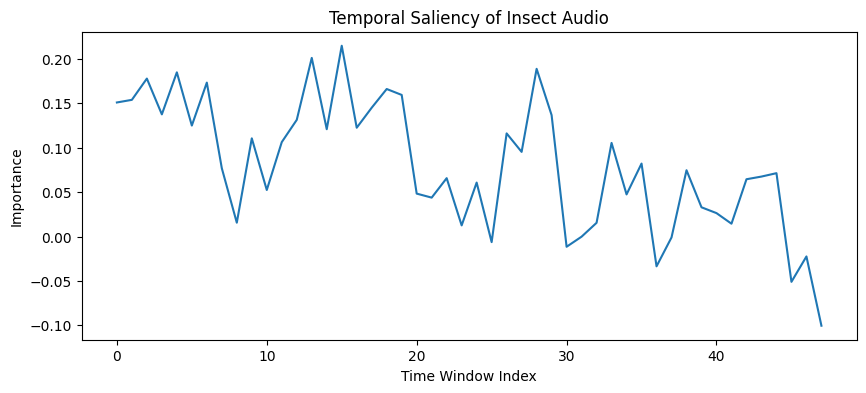

In [27]:
# =========================
# XAI 2: Temporal Saliency (Audio-level)
# =========================

import numpy as np
import matplotlib.pyplot as plt

def temporal_saliency(waveform, model, yamnet_model, window=1600, step=800):
    """
    waveform: np.ndarray (1D)
    """

    # Base prediction
    base_embed = build_embedding_from_yamnet(yamnet_model, waveform)
    base_pred = model.predict(base_embed.reshape(1, -1))[0][0]

    importance = []

    for start in range(0, len(waveform) - window, step):
        masked = waveform.copy()
        masked[start:start + window] = 0.0

        emb = build_embedding_from_yamnet(yamnet_model, masked)
        pred = model.predict(emb.reshape(1, -1))[0][0]

        importance.append(base_pred - pred)

    return np.array(importance)
# run
audio_path = "/kaggle/input/insectsound1000/InsectSound1000/2022224-14-57_Myzus_persicae_000000_s16_ch0.wav"

waveform = load_wav_16k_mono(audio_path)

saliency = temporal_saliency(waveform, model, yamnet)

plt.figure(figsize=(10,4))
plt.plot(saliency)
plt.title("Temporal Saliency of Insect Audio")
plt.xlabel("Time Window Index")
plt.ylabel("Importance")
plt.show()

In [28]:
X_val = []
y_val = []

for x_batch, y_batch in val_ds:
    X_val.append(x_batch.numpy())
    y_val.append(y_batch.numpy())

X_val = np.vstack(X_val)
y_val = np.hstack(y_val)

Explained variance ratio: [0.87382454 0.0635632 ]
Total variance explained: 0.9373877


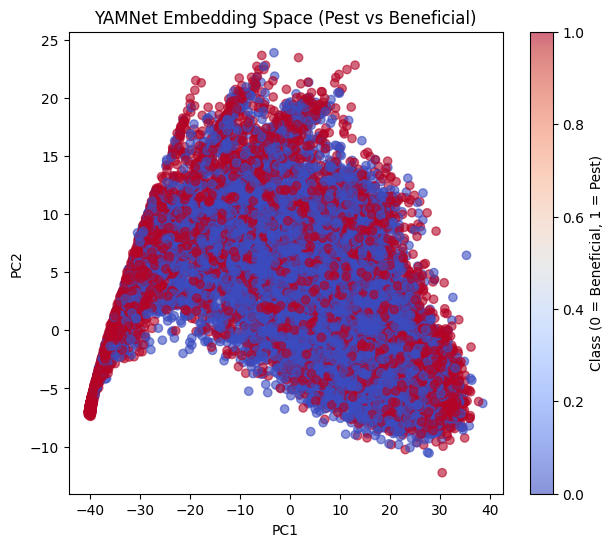

In [29]:
# =========================
# XAI: PCA on YAMNet Embeddings (Validation Set)
# =========================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_val)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_val,
    cmap="coolwarm",
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("YAMNet Embedding Space (Pest vs Beneficial)")
plt.colorbar(label="Class (0 = Beneficial, 1 = Pest)")
plt.show()

# <u>Re-Training Model with Noisy Data:</u> 

In [30]:

# Function to add noise to dataset
def add_noise(waveform, noise_factor=0.005):
    noise = tf.random.normal(shape=tf.shape(waveform), mean=0.0, stddev=1.0)
    return waveform + noise_factor * noise

In [31]:
# Function to add noise while extracting embeddings
def extembed_noisy(file_path, label):
    waveform = load_mono_tf(file_path)
    waveform_noisy = add_noise(waveform)  # inject noise
    scores, embeddings, spectrogram = yamnet(waveform_noisy)


    mean = tf.reduce_mean(embeddings, axis=0)
    std  = tf.math.reduce_std(embeddings, axis=0)
    embedding = tf.concat([mean, std], axis=0)
    return embedding, label


noisy_val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(extembed_noisy, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(512)
    .prefetch(tf.data.AUTOTUNE)
)

In [32]:
# CNN Architecture
# model2 = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(2048,)),  
#     tf.keras.layers.Dense(512, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(256, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(1, activation='sigmoid')
# ])


strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    model2 = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2048,)),   # pooled embedding
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

    

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


In [33]:
# Model compilation
# model2.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180,673 (4.50 MB)

 Trainable params: 1,180,673 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
 #Model Training
history = model2.fit(
    train_ds,
    validation_data=noisy_val_ds,
    epochs=3,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 1571s 16s/step - accuracy: 0.6538 - loss: 0.6449 - val_accuracy: 0.5000 - val_loss: 0.7269
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 1548s 16s/step - accuracy: 0.7656 - loss: 0.4802 - val_accuracy: 0.5000 - val_loss: 0.6894
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 1550s 16s/step - accuracy: 0.8108 - loss: 0.4201 - val_accuracy: 0.5100 - val_loss: 0.6876


In [35]:
# Model Evaluation
loss, acc = model2.evaluate(noisy_val_ds)
print(f"Noisy test set accuracy: {acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.5147 - loss: 0.6864
Noisy test set accuracy: 0.5098


In [36]:
# Confusion matrix of the noisy data


y_true = []
y_pred = []

for x_batch, y_batch in noisy_val_ds:
    preds = model.predict(x_batch)
    preds = (preds > 0.5).astype("int32")
    y_true.extend(y_batch.numpy())
    y_pred.extend(preds.flatten())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


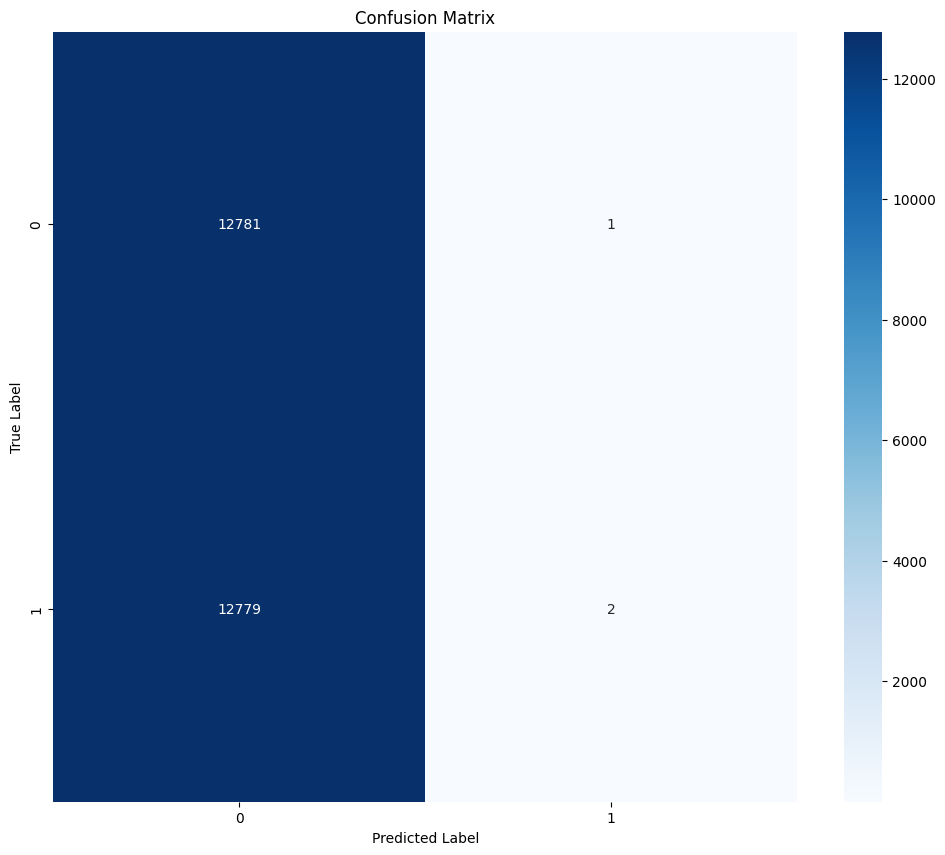

In [37]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
cls = le.classes_
labels = np.unique(np.concatenate((y_val, y_pred)))
comb = [cls[i] for i in labels]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=comb, yticklabels=comb)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


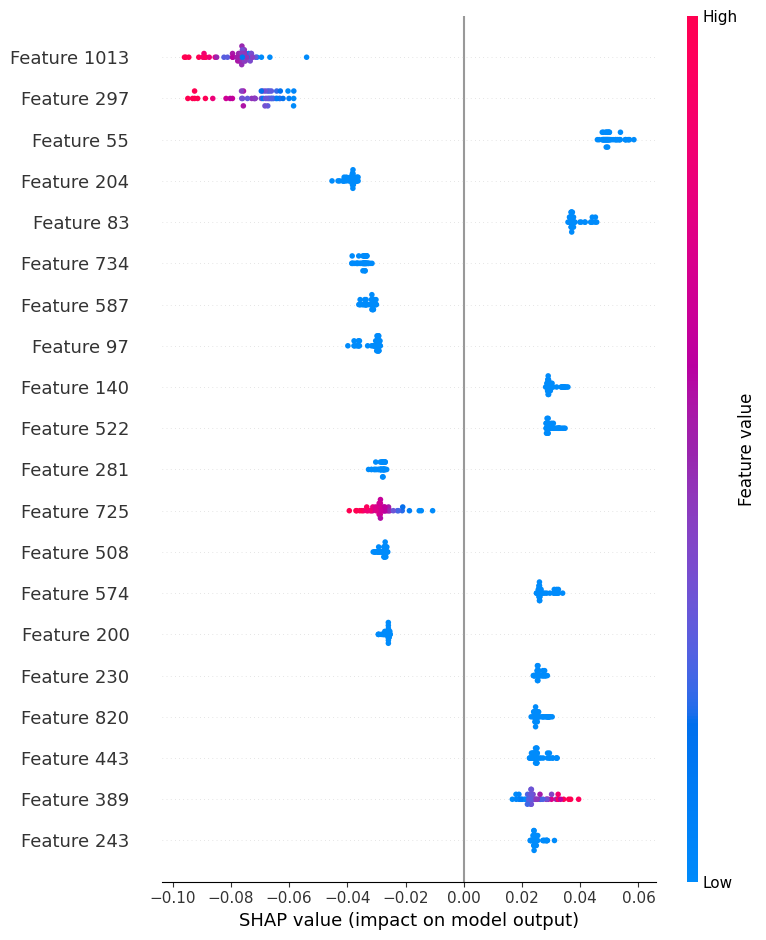

In [38]:
# =========================
# Utility: Extract embeddings from a dataset
# =========================

import numpy as np

def extract_embeddings(ds, max_batches=None):
    X, y = [], []
    for i, (x_batch, y_batch) in enumerate(ds):
        X.append(x_batch.numpy())
        y.append(y_batch.numpy())
        if max_batches and i >= max_batches - 1:
            break
    return np.vstack(X), np.hstack(y)


# =========================
# SHAP – Noisy data
# =========================

X_noisy, y_noisy = extract_embeddings(noisy_val_ds, max_batches=5)

X_explain_noisy = X_noisy[:50]
shap_vals_noisy = explainer.shap_values(X_explain_noisy)
shap_vals_noisy = np.squeeze(shap_vals_noisy, axis=-1)

shap.summary_plot(shap_vals_noisy, X_explain_noisy, show=True)

In [39]:
# =========================
# Utility: YAMNet → 2048-D embedding
# =========================

def build_embedding(yamnet, waveform):
    _, embeddings, _ = yamnet(waveform)
    emb = embeddings.numpy()
    return np.concatenate([emb.mean(axis=0), emb.std(axis=0)])


# =========================
# Temporal saliency
# =========================

def temporal_saliency(waveform, model, yamnet, window=1600, step=800):
    """
    waveform: np.ndarray OR tf.Tensor (1D)
    """

    # ---- FORCE NumPy (this fixes your error) ----
    if hasattr(waveform, "numpy"):
        waveform_np = waveform.numpy()
    else:
        waveform_np = waveform

    # Base prediction
    base_emb = build_embedding(yamnet, waveform_np)
    base_pred = model.predict(base_emb.reshape(1, -1))[0][0]

    importance = []

    for start in range(0, len(waveform_np) - window, step):
        masked = waveform_np.copy()
        masked[start:start + window] = 0.0

        emb = build_embedding(yamnet, masked)
        pred = model.predict(emb.reshape(1, -1))[0][0]

        importance.append(base_pred - pred)

    return np.array(importance)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

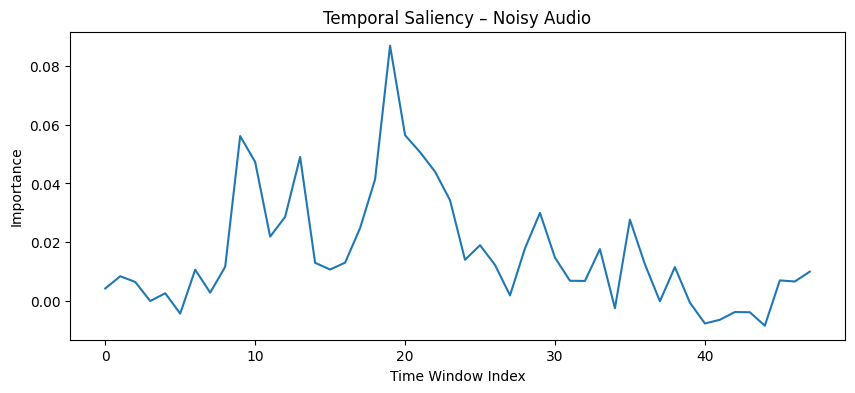

In [40]:
# assuming you already used this noise function elsewhere


waveform_noisy = add_noise(waveform)

saliency_noisy = temporal_saliency(waveform_noisy, model, yamnet)

plt.figure(figsize=(10,4))
plt.plot(saliency_noisy)
plt.title("Temporal Saliency – Noisy Audio")
plt.xlabel("Time Window Index")
plt.ylabel("Importance")
plt.show()

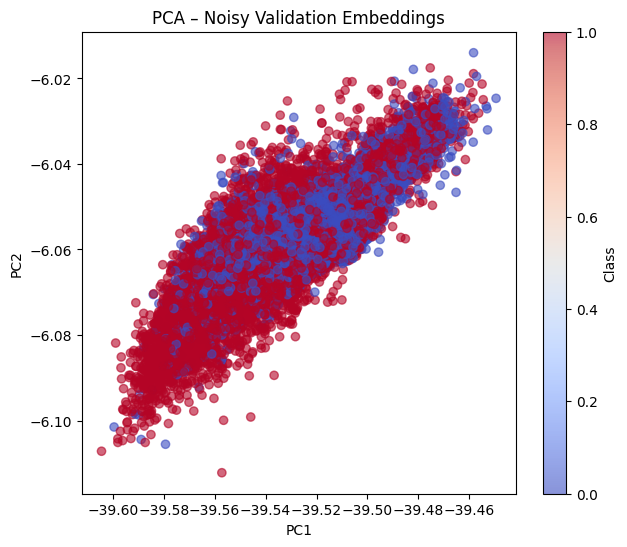

In [41]:
# =========================
# PCA – Noisy validation data
# =========================

X_noisy, y_noisy = extract_embeddings(noisy_val_ds)

X_noisy_pca = pca.transform(X_noisy)  # IMPORTANT: same PCA

plt.figure(figsize=(7,6))
plt.scatter(X_noisy_pca[:,0], X_noisy_pca[:,1], c=y_noisy, cmap="coolwarm", alpha=0.6)
plt.title("PCA – Noisy Validation Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Class")
plt.show()

# <u>Re-Training model after using noise reduction techniques</u> 

 <u> Noise reduction technique:</u> Band-Pass filtering<br>

 Band-Pass filtering is a method of noise filtering where only there relevant frequency range is kept and the extra frequencies (noise) are normalized/attenuated.<br>
 Helps in removing unwanted hisses, static, bass, hum, etc that happens when operating under real world conditions.

In [42]:
# Function to extract embeddings from the model after applying bnd pass filtering
def extembed_filtered(file_path, label):
    waveform = load_mono_tf(file_path)
    waveform_filtered = tf.py_function(
        func=lambda x: bandpass_filter(x, sr=16000),
        inp=[waveform],
        Tout=tf.float32
    )
    waveform_filtered.set_shape([None])
    scores, embeddings, spectrogram = yamnet(waveform_filtered)
    mean = tf.reduce_mean(embeddings, axis=0)
    std  = tf.math.reduce_std(embeddings, axis=0)
    embedding = tf.concat([mean, std], axis=0)

    return embedding, label

# Build noisy+filtered validation dataset
val_ds_filtered = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(extembed_filtered, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(512)
    .prefetch(tf.data.AUTOTUNE)
)

def gaussian_filter_waveform(waveform, sigma=1.0):
    if isinstance(waveform, tf.Tensor):
        waveform = waveform.numpy()
    filtered = gaussian_filter1d(waveform, sigma=sigma)
    return tf.convert_to_tensor(filtered, dtype=tf.float32)




def extembed_gaussian(file_path, label):
    waveform = load_mono_tf(file_path)
    waveform_filtered = tf.py_function(
        func=lambda x: gaussian_filter_waveform(x, sigma=1.0),
        inp=[waveform],
        Tout=tf.float32
    )
    waveform_filtered.set_shape([None])

    # Pass filtered waveform into YAMNet
    scores, embeddings, spectrogram = yamnet(waveform_filtered)

    # Pool embeddings into fixed vector
    mean = tf.reduce_mean(embeddings, axis=0)
    std  = tf.math.reduce_std(embeddings, axis=0)
    embedding = tf.concat([mean, std], axis=0)

    return embedding, label


In [43]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import butter, sosfilt

# Gaussian filtering provides extra helo ti band pass filtering by improving validation accuracy

# Function to implement band-pass filtering
def bandpass_filter(waveform, sr=16000, low=200, high=8000):
    # If it's a TensorFlow tensor, convert to NumPy
    if isinstance(waveform, tf.Tensor):
        waveform = waveform.numpy()

    # Now waveform is a NumPy array
    stft = librosa.stft(waveform)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=stft.shape[0]*2-1)

    # Mask frequencies outside desired band
    mask = (freqs >= low) & (freqs <= high)
    stft_filtered = stft[mask, :]

    # Inverse transform back to waveform
    filtered = librosa.istft(stft_filtered)
    return filtered


    # Mask frequencies outside desired band
    mask = (freqs >= low) & (freqs <= high)
    stft_filtered = stft[mask, :]

    # Inverse transform back to waveform
    filtered = librosa.istft(stft_filtered)
    return tf.convert_to_tensor(filtered, dtype=tf.float32)


# Function to apply gaussian and band pass filtering onto the noisy dataset
def bandpass_then_gaussian(waveform, sr=16000, low=200, high=7900, sigma=1.0):
  
    if isinstance(waveform, tf.Tensor):
        waveform = waveform.numpy()
    sos = butter(N=4, Wn=[low, high], btype='band', fs=sr, output='sos')
    bp_filtered = sosfilt(sos, waveform)
    smoothed = gaussian_filter1d(bp_filtered, sigma=sigma)

    return tf.convert_to_tensor(smoothed, dtype=tf.float32)



# Function to extract embeddings from noisy validation audio
def extembed_bandpass_gaussian(file_path, label):
    
    waveform = load_mono_tf(file_path)
    waveform_filtered = tf.py_function(
        func=lambda x: bandpass_then_gaussian(x, sr=16000, low=200, high=7900, sigma=1.0),
        inp=[waveform],
        Tout=tf.float32
    )
    waveform_filtered.set_shape([None])

    scores, embeddings, spectrogram = yamnet(waveform_filtered)
    mean = tf.reduce_mean(embeddings, axis=0)
    std  = tf.math.reduce_std(embeddings, axis=0)
    embedding = tf.concat([mean, std], axis=0)

    return embedding, label

# Validation set with filtered values
val_ds_filtered = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))   
    .map(extembed_bandpass_gaussian, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(512)
    .prefetch(tf.data.AUTOTUNE)
)

In [44]:
emb_clean = extembed(X_val[0], y_val[0])[0].numpy()
emb_filtered = extembed_bandpass_gaussian(X_val[0], y_val[0])[0].numpy()
print("Clean embedding sample:", emb_clean[:10])
print("Filtered embedding sample:", emb_filtered[:10])

print("Variance clean:", np.var(emb_clean))
print("Variance filtered:", np.var(emb_filtered))

Clean embedding sample: [0.         0.         0.15840225 0.         0.         0.
 0.         0.         0.         0.        ]
Filtered embedding sample: [0.         0.         0.5711163  0.03385052 0.         0.
 0.         0.         0.         0.        ]
Variance clean: 0.01970308
Variance filtered: 0.012236813


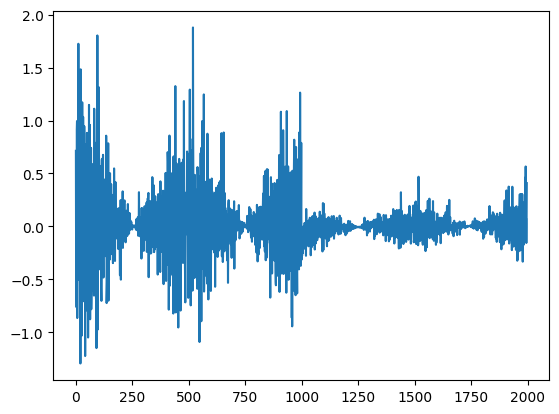

In [45]:
import matplotlib.pyplot as plt
waveform = load_mono_py(X_val[0])
filtered = bandpass_filter(waveform, sr=16000)
plt.plot(filtered)
plt.show()

In [46]:
# CNN Architecture
# model3 = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(2048,)),   
#     tf.keras.layers.Dense(512, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(256, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(1, activation='sigmoid')
# ])


# GPU-Bound distrubution
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    model3 = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2048,)),   # pooled embedding
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model3.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )


    

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


In [47]:
# Model compilation
# model3.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#         loss="binary_crossentropy",
#         metrics=["accuracy"]
# )

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180,673 (4.50 MB)

 Trainable params: 1,180,673 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
 #Model Training
history = model3.fit(
    train_ds,
    validation_data=val_ds_filtered,
    epochs=3,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 1582s 16s/step - accuracy: 0.6594 - loss: 0.6531 - val_accuracy: 0.5000 - val_loss: 0.7201
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 1720s 17s/step - accuracy: 0.7690 - loss: 0.4748 - val_accuracy: 0.4991 - val_loss: 0.6901
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 1701s 17s/step - accuracy: 0.8149 - loss: 0.4132 - val_accuracy: 0.5144 - val_loss: 0.6932


In [49]:
# Model Evaluation
loss, acc = model3.evaluate(val_ds_filtered)
print(f"Filtered noisy validation accuracy: {acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.4942 - loss: 0.6906
Filtered noisy validation accuracy: 0.4991


In [50]:
#Confusion matrix
# Confusion matrix of the noisy data


y_true = []
y_pred = []

for x_batch, y_batch in val_ds_filtered:
    preds = model.predict(x_batch)
    preds = (preds > 0.5).astype("int32")
    y_true.extend(y_batch.numpy())
    y_pred.extend(preds.flatten())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


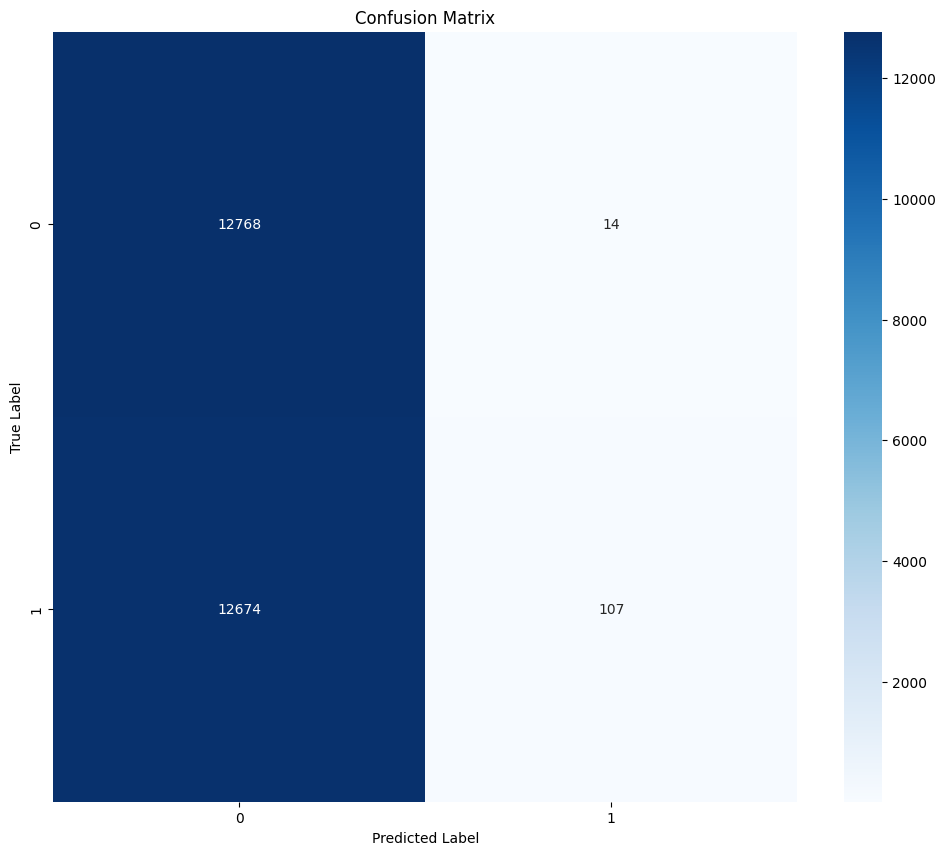

In [51]:
# Confusion matrix for denoised
cm = confusion_matrix(y_val, y_pred)
cls = le.classes_
labels = np.unique(np.concatenate((y_val, y_pred)))
comb = [cls[i] for i in labels]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=comb, yticklabels=comb)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

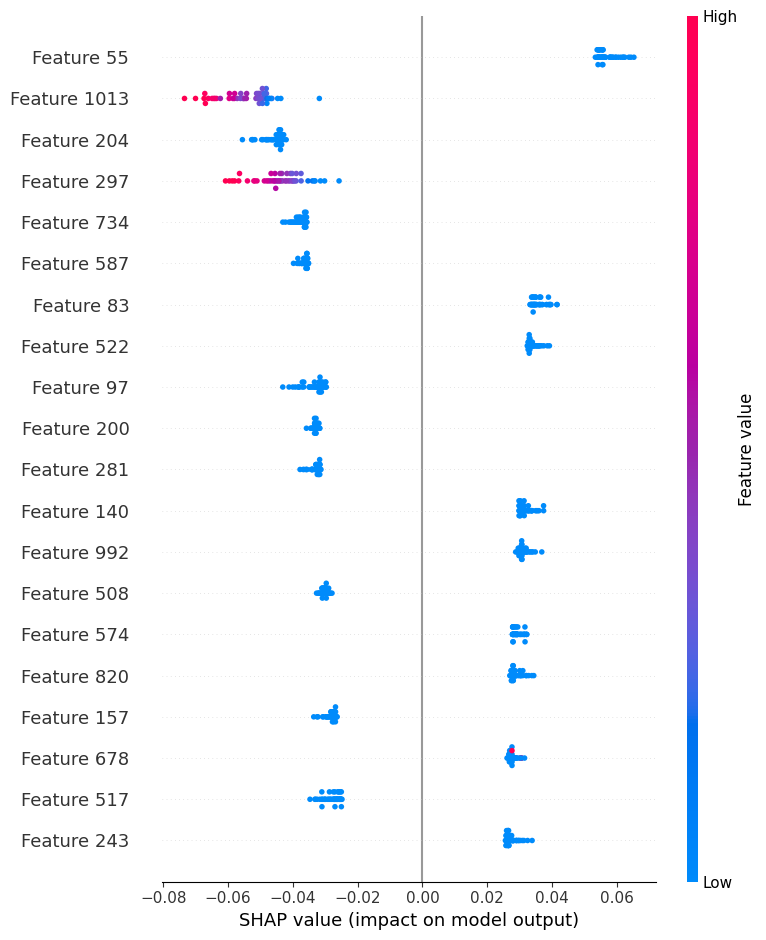

In [52]:
# SHAP ffor denoised 

X_filt, _ = extract_embeddings(val_ds_filtered, max_batches=5)
X_filt_explain = X_filt[:50]

shap_filt = explainer.shap_values(X_filt_explain)
shap_filt = np.squeeze(shap_filt, axis=-1)

shap.summary_plot(shap_filt, X_filt_explain)

In [53]:
# Temporal Saliency

# filtered waveform (band-pass denoising)
waveform_filtered = bandpass_filter(waveform_noisy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

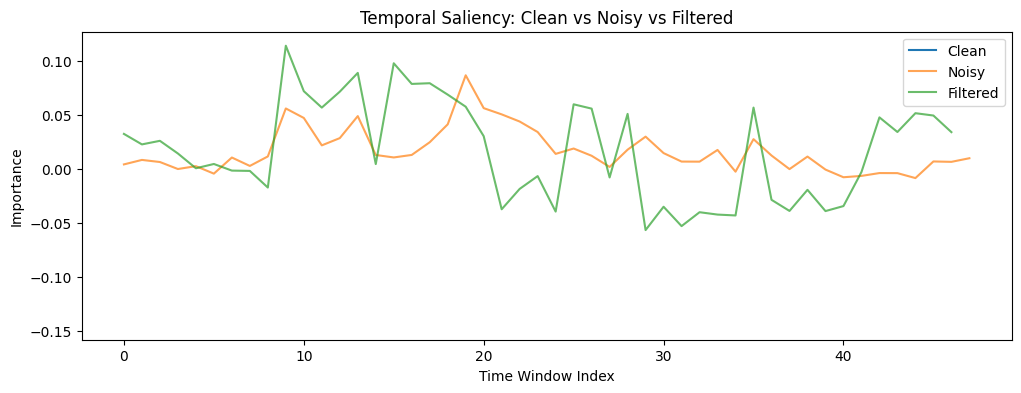

In [54]:
# for comparative saliency
sal_clean = temporal_saliency(waveform, model, yamnet)
sal_noisy = temporal_saliency(waveform_noisy, model, yamnet)
sal_filt  = temporal_saliency(waveform_filtered, model, yamnet)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(sal_clean, label="Clean")
plt.plot(sal_noisy, label="Noisy", alpha=0.7)
plt.plot(sal_filt, label="Filtered", alpha=0.7)
plt.legend()
plt.title("Temporal Saliency: Clean vs Noisy vs Filtered")
plt.xlabel("Time Window Index")
plt.ylabel("Importance")
plt.show()

In [55]:
#Comparative PCA

X_clean, y_clean = extract_embeddings(val_ds)
X_noisy, y_noisy = extract_embeddings(noisy_val_ds)
X_filt,  y_filt  = extract_embeddings(val_ds_filtered)

In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_clean_pca = pca.fit_transform(X_clean)
X_noisy_pca = pca.transform(X_noisy)
X_filt_pca  = pca.transform(X_filt)

print("Total variance explained:", pca.explained_variance_ratio_.sum())

Total variance explained: 0.9373877


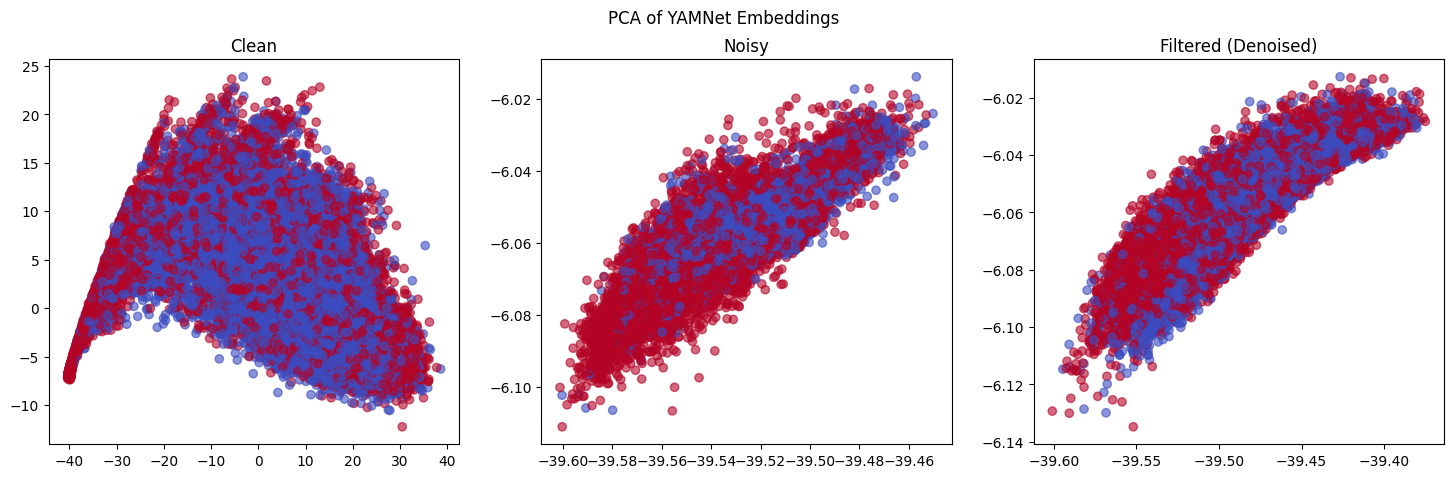

In [57]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.scatter(X_clean_pca[:,0], X_clean_pca[:,1], c=y_clean, cmap="coolwarm", alpha=0.6)
plt.title("Clean")

plt.subplot(1,3,2)
plt.scatter(X_noisy_pca[:,0], X_noisy_pca[:,1], c=y_noisy, cmap="coolwarm", alpha=0.6)
plt.title("Noisy")

plt.subplot(1,3,3)
plt.scatter(X_filt_pca[:,0], X_filt_pca[:,1], c=y_filt, cmap="coolwarm", alpha=0.6)
plt.title("Filtered (Denoised)")

plt.suptitle("PCA of YAMNet Embeddings")
plt.show()